<a href="https://colab.research.google.com/github/kabilankalaiselvi2010-collab/World-Bank-Inflation-Analysis/blob/main/An_Analysis_of_Inflation_and_Purchasing_Power_Vulnerability_Across_Economies.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Inflation, Income, and Purchasing Power: A Cross-Country Analysis**

**Introduction**


Inflation represents the rate at which the general price level of goods and services rises over time, directly affecting the purchasing power of individuals. However, its impact is not uniform across countries. The same inflation rate can have significantly different consequences depending on the economic capacity of a country, particularly the income levels of its population.


This study investigates the relationship between inflation and economic capacity using GDP per capita as a proxy for average income. By comparing countries with differing income levels and inflation patterns—India, United States, Germany, Netherlands, and Turkiye—the analysis aims to evaluate how vulnerable populations are to declines in purchasing power.


The study combines time-series analysis of inflation trends with a cross-sectional comparison of inflation and GDP per capita using the most recent available data. In addition, a simple regression model is applied to quantify the relationship between income levels and inflation. The objective is not only to identify patterns but also to assess whether economic capacity influences the real impact of inflation.

**Methodology**


Data on inflation (annual percentage change in consumer prices) and GDP per capita (current US dollars) were obtained from the World Bank database. The analysis focuses on five countries: India, United States, Germany, Netherlands, and Turkiye.

The datasets were processed using Python in Google Colab. Relevant country data was extracted and transformed from wide to long format to enable analysis across time. Data cleaning included removing non-numeric entries, converting variables such as year and inflation into numerical formats, and handling missing values.

The analysis consists of two components. First, inflation trends over time were visualized for each country to observe patterns and fluctuations. Second, a cross-sectional comparison was conducted using the most recent available data by plotting inflation against GDP per capita.

A simple linear regression model was applied to estimate the relationship between GDP per capita and inflation. Results are interpreted cautiously due to the limited sample size and the presence of outliers.

**Data Processing and Visualization**

The following code was used to clean, process, and visualize the data used in this analysis.

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving GDP per capita.csv to GDP per capita.csv


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Inflation.csv to Inflation.csv


In [ ]:
import pandas as pd
# Loading datasets (skip metadata rows)
inflation = pd.read_csv("Inflation.csv", skiprows=4)
gdp = pd.read_csv("GDP per capita.csv", skiprows=4)

# Selecting countries
countries = ["India", "United States", "Germany", "Netherlands", "Turkiye"]

# Filtering inflation data
inflation_filtered = inflation[inflation["Country Name"].isin(countries)]

# Show result
inflation_filtered.head()

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,Unnamed: 70
55,Germany,DEU,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,1.536612,2.293695,2.843270,2.966960,2.335736,3.242319,...,1.509495,1.732169,1.445660,0.144878,3.066667,6.872574,5.946437,2.256498,NaN,NaN
109,India,IND,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,1.779878,1.695213,3.632215,2.946161,13.355261,9.474759,...,3.328173,3.938826,3.729506,6.623437,5.131407,6.699034,5.649143,4.953036,NaN,NaN
176,Netherlands,NLD,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,2.323944,1.307639,2.431123,3.243647,5.823768,3.908038,...,1.381459,1.703498,2.633699,1.272460,2.675720,10.001208,3.838394,3.347543,NaN,NaN
244,Turkiye,TUR,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,5.664740,3.172857,3.888320,6.362707,1.119638,4.555534,...,11.144311,16.332464,15.176822,12.278957,19.596493,72.308836,53.859409,58.506451,NaN,NaN
251,United States,USA,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,1.457976,1.070724,1.198773,1.239669,1.278912,1.585169,...,2.130110,2.442583,1.812210,1.233584,4.697859,8.002800,4.116338,2.949525,NaN,NaN


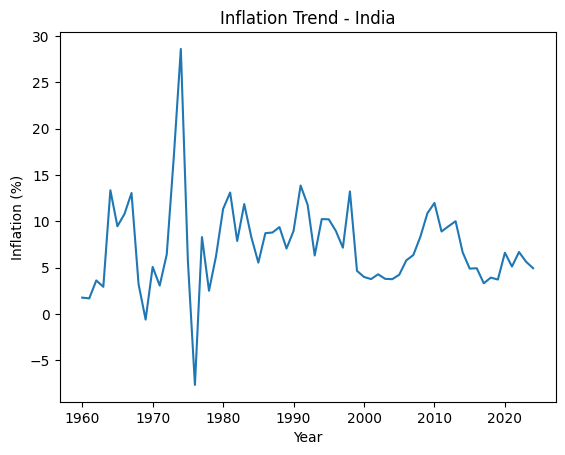

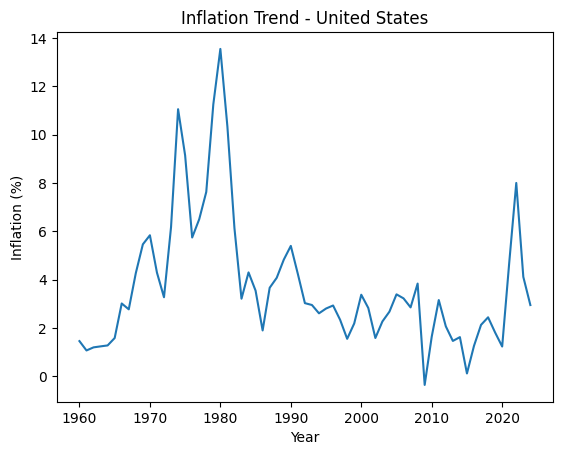

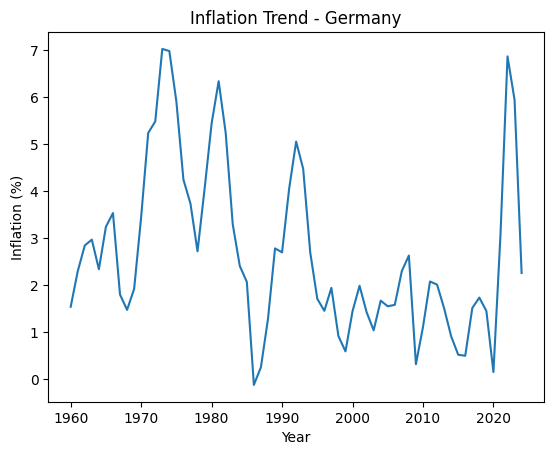

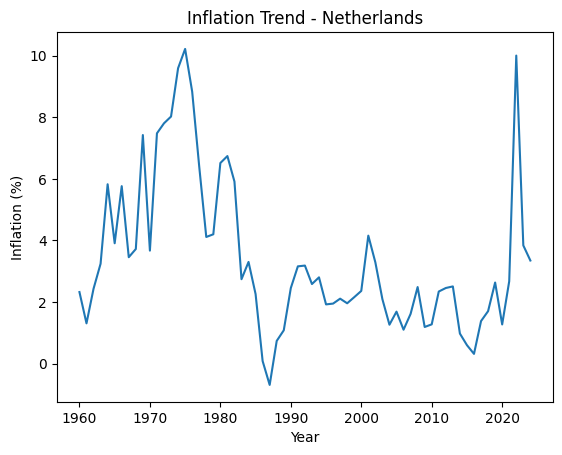

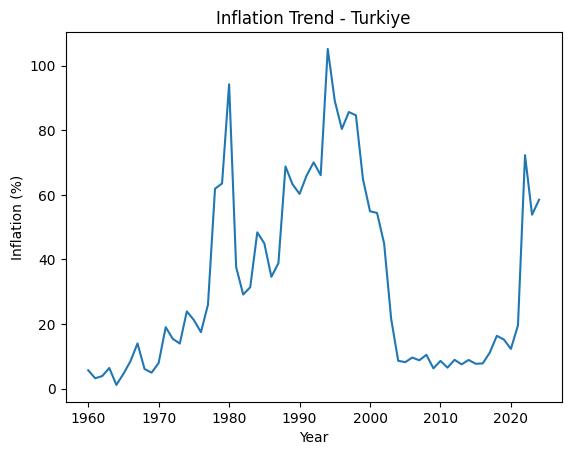

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

inflation = pd.read_csv("Inflation.csv", skiprows=4)

countries = ["India", "United States", "Germany", "Netherlands", "Turkiye"]

inflation_filtered = inflation[inflation["Country Name"].isin(countries)]

#Convert from wide → long format
inflation_long = inflation_filtered.melt(
    id_vars=["Country Name"],
    var_name="Year",
    value_name="Inflation"
)

inflation_long = inflation_long[inflation_long["Year"].str.isnumeric()]

inflation_long["Year"] = inflation_long["Year"].astype(int)
inflation_long["Inflation"] = pd.to_numeric(inflation_long["Inflation"], errors='coerce')

inflation_long = inflation_long.dropna()

for country in countries:
    data = inflation_long[inflation_long["Country Name"] == country]


    plt.figure()
    plt.plot(data["Year"], data["Inflation"])
    plt.title(f"Inflation Trend - {country}")
    plt.xlabel("Year")
    plt.ylabel("Inflation (%)")
    plt.show()

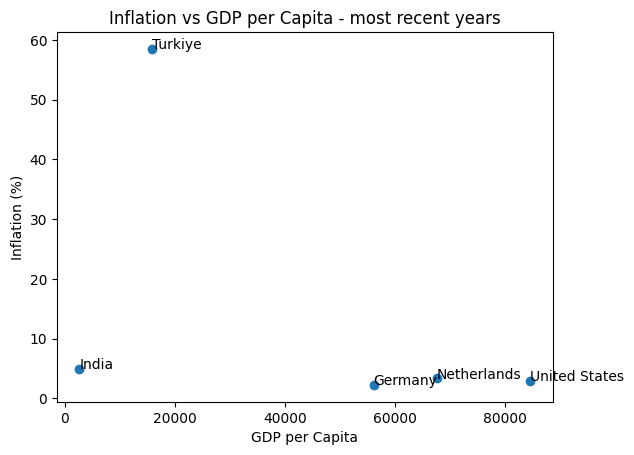

In [ ]:
gdp_filtered = gdp[gdp["Country Name"].isin(countries)]

gdp_long = gdp_filtered.melt(
    id_vars=["Country Name"],
    var_name="Year",
    value_name="GDP"
)

gdp_long = gdp_long[gdp_long["Year"].str.isnumeric()]

gdp_long["Year"] = gdp_long["Year"].astype(int)
gdp_long["GDP"] = pd.to_numeric(gdp_long["GDP"], errors='coerce')

gdp_long = gdp_long.dropna()

merged = pd.merge(
    inflation_long,
    gdp_long,
    on=["Country Name", "Year"],
    how="inner"
)

latest = merged.sort_values("Year").groupby("Country Name").tail(1)

plt.figure()
plt.scatter(latest["GDP"], latest["Inflation"])

for i, country in enumerate(latest["Country Name"]):
    plt.annotate(country, (latest["GDP"].iloc[i], latest["Inflation"].iloc[i]))

plt.xlabel("GDP per Capita")
plt.ylabel("Inflation (%)")
plt.title("Inflation vs GDP per Capita - most recent years")

plt.show()

In [ ]:
latest = merged.sort_values("Year").groupby("Country Name").tail(1)
from sklearn.linear_model import LinearRegression
import numpy as np

# X = GDP (independent variable)
X = latest[["GDP"]]

# Y = Inflation (dependent variable)
y = latest["Inflation"]

# Create model
model = LinearRegression()

# Fit model
model.fit(X, y)

# Get results
slope = model.coef_[0]
intercept = model.intercept_
r_squared = model.score(X, y)

print("Slope:", slope)
print("Intercept:", intercept)
print("R^2:", r_squared)

Slope: -0.000356248367621634
Intercept: 30.55816395724831
R^2: 0.2516915048421762


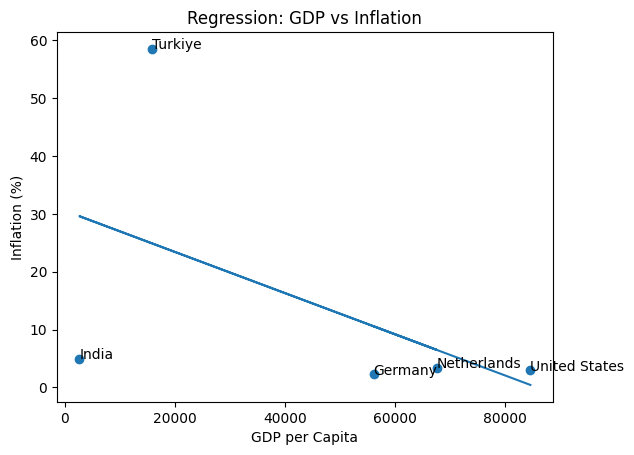

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(X, y)

# Regression line
plt.plot(X, model.predict(X))

# Labels
for i, country in enumerate(latest["Country Name"]):
    plt.annotate(country, (X.iloc[i, 0], y.iloc[i]))

plt.xlabel("GDP per Capita")
plt.ylabel("Inflation (%)")
plt.title("Regression: GDP vs Inflation")

plt.show()

**Data analysis**

The analysis is structured in three parts: inflation trends, cross-country comparison, and regression analysis.

A. Inflation Trends

The time-series data reveals clear differences in inflation stability across countries. Germany and Netherlands exhibit relatively stable inflation over time, with fluctuations generally remaining within a low range. Similarly, United States shows moderate variability, with notable spikes during certain periods but overall controlled inflation.

In contrast, India displays greater variability, including periods of high inflation and occasional negative inflation, indicating less stability. The most extreme case is Turkiye, which demonstrates significant volatility, with inflation reaching exceptionally high levels, particularly in recent years. This highlights substantial macroeconomic instability compared to the other countries.

B. Cross-Country Comparison

The scatter plot of inflation against GDP per capita (based on the most recent available data) reveals a general pattern in which higher-income countries tend to experience lower inflation. Germany, Netherlands, and United States are clustered together, characterized by high GDP per capita and relatively low inflation rates. This clustering suggests a degree of convergence among developed economies in maintaining price stability.

However, the relationship is not uniform. India, despite having moderate inflation, is positioned at a significantly lower GDP level, indicating that similar inflation rates can have more severe implications in lower-income contexts.
A major deviation from the observed pattern is Turkiye, which exhibits extremely high inflation despite having a mid-range GDP per capita. This outlier significantly affects the overall distribution and suggests that factors beyond income level—such as economic policy and stability—play a critical role in determining inflation outcomes.

C. Regression Analysis

The regression model indicates a negative relationship between GDP per capita and inflation, suggesting that higher-income countries tend to have lower inflation rates. However, the strength of this relationship is limited, as reflected in a low explanatory power (R²). This weak fit is largely influenced by the small sample size and the presence of outliers, particularly Turkiye, which distorts the overall trend.

**Final analysis**

The findings suggest that inflation cannot be evaluated independently of economic context. While higher GDP per capita is generally associated with greater price stability, it does not fully determine inflation outcomes. More importantly, the impact of inflation on purchasing power is not uniform across countries.

In higher-income economies such as Germany and United States, relatively low and stable inflation indicates a greater capacity to absorb price increases. In contrast, in lower-income contexts such as India, even moderate inflation can impose a significant burden on consumers due to lower income levels.

The case of Turkiye demonstrates that inflation can escalate dramatically even in economies that are not the poorest, highlighting the influence of country-specific factors such as economic policy, institutional stability, and external shocks. This suggests that inflation is not solely determined by income levels, but by a broader set of structural and policy-related factors.

Overall, the analysis indicates that the economic consequences of inflation are fundamentally relative. The same inflation rate can have vastly different effects depending on a country’s economic capacity, making it essential to evaluate inflation alongside income measures rather than in isolation. This suggests that inflation should be interpreted as a relative economic pressure rather than an absolute metric.

**Conclusion**

This study concludes that while there is a general tendency for higher-income countries to experience lower and more stable inflation, this relationship is not definitive. More importantly, the impact of inflation is context-dependent and varies significantly based on economic capacity.

Lower-income economies are more vulnerable to the effects of inflation, even at moderate levels, due to limited income buffers. At the same time, extreme cases such as Turkiye illustrate that high inflation can arise independently of income level, driven by broader economic conditions.

Therefore, a meaningful assessment of inflation must consider both price changes and income levels. Evaluating inflation in isolation provides an incomplete picture, whereas incorporating economic capacity allows for a more accurate understanding of its real impact on purchasing power.

**Evaluation**

While the analysis provides useful insights into the relationship between inflation and economic capacity, several limitations should be considered. First, the study is based on a small sample of five countries, which restricts the ability to generalise findings across a broader range of economies. This limitation is reflected in the regression results, where the model explains only a small proportion of the variation in inflation (R² ≈ 0.25), indicating that GDP per capita alone is not a strong predictor of inflation.

In addition, the presence of a significant outlier—Turkiye—has a disproportionate influence on both the scatter plot and the regression model. Its exceptionally high inflation levels distort the overall trend, potentially exaggerating the apparent negative relationship between GDP per capita and inflation.

Another limitation arises from the use of GDP per capita as a proxy for income. While it provides a useful measure of average economic capacity, it does not account for income distribution within countries, and therefore may not accurately reflect the purchasing power of all individuals.

Finally, the cross-sectional analysis is based on the most recent available data for each country, which may not correspond to the same year. This introduces a degree of inconsistency, as inflation and GDP conditions can vary significantly across time.

These limitations suggest that while the analysis identifies general patterns, the results should be interpreted with caution, and further investigation using larger datasets and additional variables would be required for more robust conclusions.

**References**

World Bank. (2025). Inflation, consumer prices (annual %). Retrieved from https://data.worldbank.org

World Bank. (2025). GDP per capita (current US$). Retrieved from https://data.worldbank.org